In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

/home/comp/.local/lib/python3.6/site-packages/pandas/compat/_optional.py:124: UserWarning: Pandas requires version '1.2.1' or newer of 'bottleneck' (version '1.2.0' currently installed).
  warnings.warn(msg, UserWarning)


### Loading the dataset

In [2]:

df = pd.read_csv('Google Stock Prices Dataset.csv')

train_df, test_df = train_test_split(df, test_size=0.2, shuffle=False)

#### Choosing column 'open' for predicition

In [3]:
train = train_df.loc[:,["Open"]].values
train.shape

(1007, 1)

### Feature Scaling

In [4]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [5]:
train_scaled = scaler.fit_transform(train)

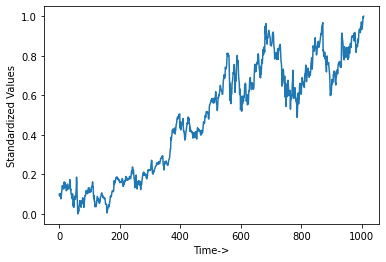

In [6]:
plt.plot(train_scaled)
plt.ylabel("Standardized Values")
plt.xlabel("Time->")
plt.show()

In [7]:
x_train = []
y_train = []
time = 60
for i in range(60,train_scaled.shape[0]):
    x_train.append(train_scaled[i-60:i,0])
    y_train.append(train_scaled[i,0])
x_train = np.array(x_train)
y_train = np.array(y_train)

In [8]:
x_train.shape,y_train.shape

((947, 60), (947,))

In [9]:
x_train = np.reshape(x_train,newshape=(x_train.shape[0],x_train.shape[1],1))
x_train.shape

(947, 60, 1)

### Build model

In [10]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN,Dropout

In [11]:
model = Sequential()

model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True, 
                    input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam',loss='mse')
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn (SimpleRNN)       (None, 60, 50)            2600      
_________________________________________________________________
dropout (Dropout)            (None, 60, 50)            0         
_________________________________________________________________
simple_rnn_1 (SimpleRNN)     (None, 60, 50)            5050      
_________________________________________________________________
dropout_1 (Dropout)          (None, 60, 50)            0         
_________________________________________________________________
simple_rnn_2 (SimpleRNN)     (None, 60, 50)            5050      
_________________________________________________________________
dropout_2 (Dropout)          (None, 60, 50)            0         
_________________________________________________________________
simple_rnn_3 (SimpleRNN)     (None, 50)                5

In [12]:
model.fit(x_train,y_train,epochs=100,batch_size=30,validation_split=0.05)

Epoch 1/100
30/30 [==============================] - 4s 46ms/step - loss: 0.4127 - val_loss: 0.0033
Epoch 2/100
30/30 [==============================] - 1s 36ms/step - loss: 0.3151 - val_loss: 0.0287
Epoch 3/100
30/30 [==============================] - 1s 36ms/step - loss: 0.3010 - val_loss: 0.0023
Epoch 4/100
30/30 [==============================] - 1s 36ms/step - loss: 0.2098 - val_loss: 0.0078
Epoch 5/100
30/30 [==============================] - 1s 36ms/step - loss: 0.1738 - val_loss: 0.0206
Epoch 6/100
30/30 [==============================] - 1s 36ms/step - loss: 0.1319 - val_loss: 0.0066
Epoch 7/100
30/30 [==============================] - 1s 36ms/step - loss: 0.1318 - val_loss: 0.0032
Epoch 8/100
30/30 [==============================] - 1s 36ms/step - loss: 0.1004 - val_loss: 0.0182
Epoch 9/100
30/30 [==============================] - 1s 37ms/step - loss: 0.0899 - val_loss: 0.0342
Epoch 10/100
30/30 [==============================] - 1s 36ms/step - loss: 0.0851 - val_loss: 0.0104

### Prepare test dataset

In [13]:
data = pd.concat((train_df['Open'],test_df['Open']),axis=0)

In [14]:
test_input = data.iloc[len(data) - len(test_df) - time : ].values
test_input.shape

(312,)

In [15]:
test_input = test_input.reshape(-1,1)
test_input.shape

(312, 1)

In [16]:
test_scaled = scaler.transform(test_input)

#### Create test data set

In [17]:
x_test = []
for i in range(time,test_scaled.shape[0]):
    x_test.append(test_scaled[i - time: i,0 ])
x_test = np.array(x_test)
x_test.shape

(252, 60)

In [18]:
x_test = np.reshape(x_test,newshape=(x_test.shape[0],x_test.shape[1],1))
x_test.shape

(252, 60, 1)

In [19]:
y_test = test_df.loc[:,"Open"].values

### Model Prediction

In [20]:
y_pred = model.predict(x_test)

In [21]:
y_pred = scaler.inverse_transform(y_pred)

In [22]:
output = model.evaluate(x=x_test,y=y_test)

8/8 [==============================] - 0s 11ms/step - loss: 2019672.8750


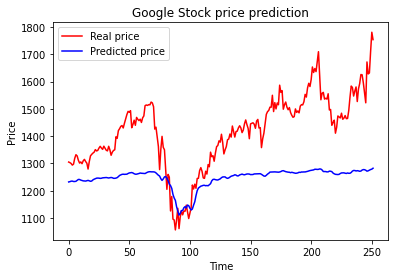

In [23]:
plt.plot(y_test, color = 'red', label = 'Real price')
plt.plot(y_pred, color = 'blue', label = 'Predicted price')

plt.title('Google Stock price prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()